<a href="https://colab.research.google.com/github/T3CHEMIL3/Inventory/blob/main/bedoccupancy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
from datetime import timedelta, datetime

admission = pd.read_csv('/content/admissions.csv')
#admission.head()

# Convert Admission Date column (format is '19-Mar-25')
admission['Admission Date'] = pd.to_datetime(admission['Admission Date'], format='%d-%b-%y')

# Simulate Discharge Date (if 'Discharged' add 5 days, else use today)
admission['Discharge Date'] = admission.apply(
    lambda row: row['Admission Date'] + timedelta(days=5)
    if row['Admission Status'].lower() == 'discharged'
    else pd.Timestamp.today(),
    axis=1
)

admission[['Admission Date', 'Discharge Date', 'Admission Status']].head()








,Admission Date,Discharge Date,Admission Status
0,2025-03-19,2025-03-24 00:00:00.000000,Discharged
1,2025-03-17,2025-03-22 00:00:00.000000,Discharged
2,2025-03-16,2025-03-21 00:00:00.000000,Discharged
3,2025-03-20,2025-03-25 00:00:00.000000,Discharged
4,2025-03-17,2025-05-01 07:36:31.281097,In Ward


In [9]:
# Create daily date range
date_range = pd.date_range(start=admission['Admission Date'].min(), end=pd.Timestamp.today())

# Initialize occupancy DataFrame
occupancy_df = pd.DataFrame({'date': date_range})
occupancy_df['occupied_beds'] = 0

# Fill occupancy count
for _, row in admission.iterrows():
    stay_period = pd.date_range(start=row['Admission Date'], end=row['Discharge Date'])
    occupancy_df.loc[occupancy_df['date'].isin(stay_period), 'occupied_beds'] += 1

# Add target label: 1 if more than 90 beds, else 0
occupancy_df['need_more_beds'] = (occupancy_df['occupied_beds'] > 90).astype(int)

occupancy_df.head()

,date,occupied_beds,need_more_beds
0,2025-02-25,1,0
1,2025-02-26,1,0
2,2025-02-27,1,0
3,2025-02-28,1,0
4,2025-03-01,1,0


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#features and labels
X = occupancy_df[['occupied_beds']]
y = occupancy_df['need_more_beds']

#split the dataset
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#train the model
model = LogisticRegression()
model.fit(x_train, y_train)

#predict
y_pred = model.predict(x_test)

#evaluate
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[6 0]
 [0 8]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         8

    accuracy                           1.00        14
   macro avg       1.00      1.00      1.00        14
weighted avg       1.00      1.00      1.00        14



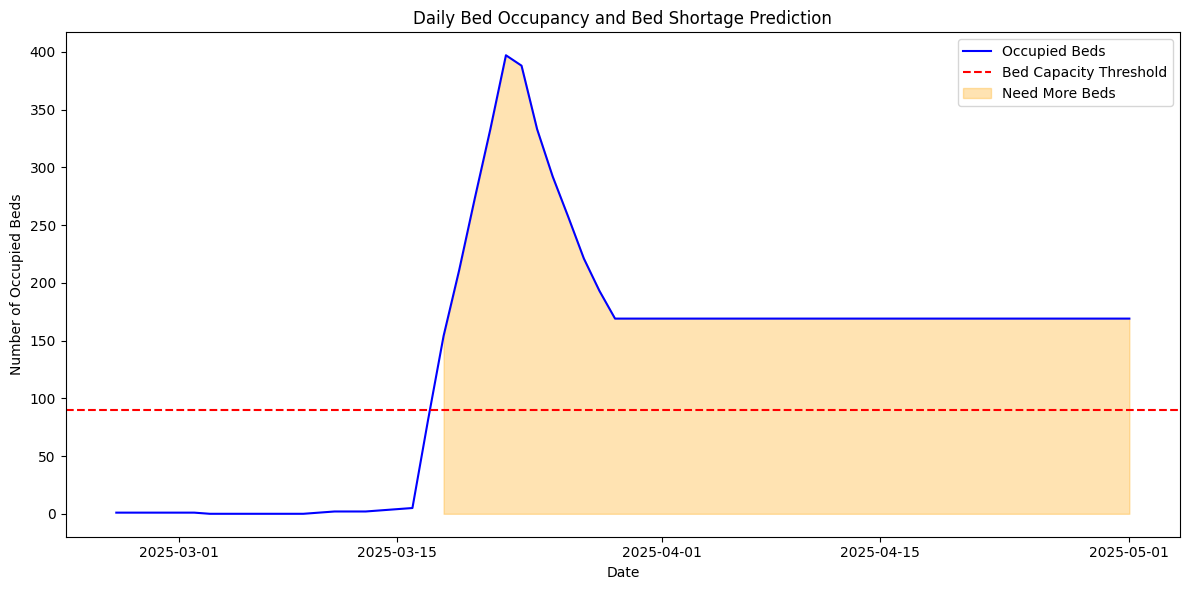

In [11]:
import matplotlib.pyplot as plt

# Plot occupancy and bed need
plt.figure(figsize=(12, 6))
plt.plot(occupancy_df['date'], occupancy_df['occupied_beds'], label='Occupied Beds', color='blue')
plt.axhline(y=90, color='red', linestyle='--', label='Bed Capacity Threshold')
plt.fill_between(occupancy_df['date'], 0, occupancy_df['occupied_beds'],
                 where=occupancy_df['need_more_beds'] == 1,
                 color='orange', alpha=0.3, label='Need More Beds')
plt.xlabel("Date")
plt.ylabel("Number of Occupied Beds")
plt.title("Daily Bed Occupancy and Bed Shortage Prediction")
plt.legend()
plt.tight_layout()
plt.show()